<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_1/blob/main/3_1_1_PRACTICE_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# 3. Pandas

Pandas is the best known Python library for manipulating and analyzing data. It is built on top of NumPy, so many features are similar. We will use Pandas to work with structured datasets.

Just as NumPy provides us with arrays and with them we access many new features, Pandas provides us with DataFrames and Series. By far the most used object is the first one, DataFrames.

We are going to use the open data of the Argentine government, so you will have to download the csv from the following link: [Names 2010-2014](https://www.datos.gob.ar/dataset/otros-nombres-personas-fisicas)

In [2]:
import pandas as pd

## Reading a csv file

In [3]:
!gdown "1rrunop8AFG7bRdVbQZWXFQAQas581ouV"

df_names = pd.read_csv('nombres-2010-2014.csv')
df_names


Downloading...
From: https://drive.google.com/uc?id=1rrunop8AFG7bRdVbQZWXFQAQas581ouV
To: /content/nombres-2010-2014.csv
100% 19.6M/19.6M [00:00<00:00, 92.8MB/s]


,nombre,cantidad,anio
0,Benjamin,2986,2010
1,Sofia,2252,2010
2,Bautista,2176,2010
3,Joaquín,2111,2010
4,Juan Ignacio,2039,2010
...,...,...,...
871489,Leire Jasmin,1,2014
871490,Isaias Sebastian Ariel,1,2014
871491,Yanira Valentina,1,2014
871492,Angie Ainara,1,2014


In [4]:
df_names.dtypes

,0
nombre,object
cantidad,int64
anio,int64


## Columns renaming

First of all let's rename the columns to `name`, `amount` and `year`

In [5]:
df_names.rename(columns={'nombre': 'name', 'cantidad': 'amount', 'anio': 'year'}, inplace=True)
df_names

,name,amount,year
0,Benjamin,2986,2010
1,Sofia,2252,2010
2,Bautista,2176,2010
3,Joaquín,2111,2010
4,Juan Ignacio,2039,2010
...,...,...,...
871489,Leire Jasmin,1,2014
871490,Isaias Sebastian Ariel,1,2014
871491,Yanira Valentina,1,2014
871492,Angie Ainara,1,2014


## Some Pandas useful functions

**TODO:** Investigate the functions that are implemented in the next cell. What do they do? What do you think they can be useful for?

In [6]:
# df_names.head()
# df_names.tail()
# df_names.tail()
# df_names.count()
df_names.shape

(871494, 3)

## Append a new row

**TODO:** Suppose that in the data load, someone forgot to add a name and its respective amount and year.

Let's add to our dataset the following row with said information:

Name: "Daenerys Stormborn of the House Targaryen, First of Her Name de ella, the Unburnt, Queen of the Andals and the First Men, Khaleesi of the Great Grass Sea, Breaker of Chains, and Mother of Dragons"

Amount: 100
Year: 2011

In [7]:
# Complete this cell with your code
# Create a dictionary with the new row data
new_row = {
    'name': 'Daenerys Stormborn of the House Targaryen, First of Her Name de ella, the Unburnt, Queen of the Andals and the First Men, Khaleesi of the Great Grass Sea, Breaker of Chains, and Mother of Dragons',
    'amount': 100,
    'year': 2011
}

# Append the new row at the end of the dataframe using loc
df_names.loc[len(df_names)] = new_row

# Display the last rows to verify
df_names.tail()

,name,amount,year
871490,Isaias Sebastian Ariel,1,2014
871491,Yanira Valentina,1,2014
871492,Angie Ainara,1,2014
871493,Elias Hernando,1,2014
871494,"Daenerys Stormborn of the House Targaryen, Fir...",100,2011


**TODO:** Investigate the columns and index functions. What do they do? What data type is their output? What known data type do they resemble?

In [8]:
df_names.columns

Index(['name', 'amount', 'year'], dtype='object')

In [9]:
df_names.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       871485, 871486, 871487, 871488, 871489, 871490, 871491, 871492, 871493,
       871494],
      dtype='int64', length=871495)

## Add a new column

**TODO:** Add a column to the dataframe that corresponds to the number of characters in each name

In [10]:
# Complete this cell with your code
# Create the new column by calculating the length of the string in the 'name' column
df_names['amount_chars'] = df_names['name'].str.len()

# Show the first rows to verify
df_names.head()

,name,amount,year,amount_chars
0,Benjamin,2986,2010,8
1,Sofia,2252,2010,5
2,Bautista,2176,2010,8
3,Joaquín,2111,2010,7
4,Juan Ignacio,2039,2010,12


## Filtering by mask

Its implementation is very similar in both NumPy and Pandas, so we will see how to do it first in NumPy then in Pandas.

Suppose we make 100 rolls of a die, but we want to select only those rolls that were less than four. How can we do it?

In [11]:
import numpy as np
dice = np.random.randint(1, 7, size=100)
print(dice)

[4 6 5 2 3 2 1 4 4 5 2 4 1 3 4 2 2 4 3 5 3 4 4 6 5 2 1 4 1 5 6 1 2 6 1 3 6
 3 1 6 5 4 6 4 6 4 1 2 2 5 6 1 6 1 1 2 4 3 2 4 2 5 5 6 5 2 4 5 2 4 3 1 4 5
 4 6 6 1 2 5 2 4 1 5 4 4 2 1 5 2 5 5 2 2 5 4 6 4 6 2]


What we can do is create a mask:

In [12]:
mask = dice > 3
print(mask)
print(type(mask))

[ True  True  True False False False False  True  True  True False  True
 False False  True False False  True False  True False  True  True  True
  True False False  True False  True  True False False  True False False
  True False False  True  True  True  True  True  True  True False False
 False  True  True False  True False False False  True False False  True
 False  True  True  True  True False  True  True False  True False False
  True  True  True  True  True False False  True False  True False  True
  True  True False False  True False  True  True False False  True  True
  True  True  True False]
<class 'numpy.ndarray'>


In [13]:
print(dice[mask])

[4 6 5 4 4 5 4 4 4 5 4 4 6 5 4 5 6 6 6 6 5 4 6 4 6 4 5 6 6 4 4 5 5 6 5 4 5
 4 4 5 4 6 6 5 4 5 4 4 5 5 5 5 4 6 4 6]


In [14]:
print(dice.sum())

353


In [15]:
print(dice[dice > 3])

[4 6 5 4 4 5 4 4 4 5 4 4 6 5 4 5 6 6 6 6 5 4 6 4 6 4 5 6 6 4 4 5 5 6 5 4 5
 4 4 5 4 6 6 5 4 5 4 4 5 5 5 5 4 6 4 6]


**TODO:** Going back to our dataset, suppose we want to keep those rows with names that were repeated more than 2000 times in the corresponding year. Note that in the result a name may appear more than once in different years

In [16]:
# Complete this cell with your code
# Filter rows where the amount is greater than 2000
mask_2000 = df_names['amount'] > 2000
df_names[mask_2000]

,name,amount,year,amount_chars
0,Benjamin,2986,2010,8
1,Sofia,2252,2010,5
2,Bautista,2176,2010,8
3,Joaquín,2111,2010,7
4,Juan Ignacio,2039,2010,12
5,Martina,2026,2010,7
6,Santiago,2012,2010,8
135000,Benjamin,2535,2011,8
254431,Benjamin,4724,2012,8
254432,Isabella,3392,2012,8


:**TODO:** What if we want to select those names with more than 8 characters and from 2010 onwards?

In [17]:
# Complete this cell with your code
# Filter rows using multiple conditions (use parenthesis for each condition and '&' for AND)
mask_complex = (df_names['amount_chars'] > 8) & (df_names['year'] >= 2010)
df_names[mask_complex]

,name,amount,year,amount_chars
4,Juan Ignacio,2039,2010,12
7,Valentina,1972,2010,9
10,Valentino,1665,2010,9
14,Francisco,1338,2010,9
25,Juan Cruz,1071,2010,9
...,...,...,...,...
871490,Isaias Sebastian Ariel,1,2014,22
871491,Yanira Valentina,1,2014,16
871492,Angie Ainara,1,2014,12
871493,Elias Hernando,1,2014,14


## Statistics

**TODO:** Obtain the mean value and standard deviation of each numeric column. Is there a function in Pandas that will give us even more statistics?

In [18]:
# Complete this cell with your code
# Calculate mean and standard deviation for numeric columns only
print("Mean values:\n", df_names.mean(numeric_only=True))
print("\nStandard Deviation:\n", df_names.std(numeric_only=True))

# The function that gives even more statistics in a single call is describe()
print("\nFull statistical summary:\n", df_names.describe())

Mean values:
 amount             4.278334
year            2012.267646
amount_chars      14.357074
dtype: float64

Standard Deviation:
 amount          34.615844
year             1.370918
amount_chars     3.677649
dtype: float64

Full statistical summary:
               amount           year   amount_chars
count  871495.000000  871495.000000  871495.000000
mean        4.278334    2012.267646      14.357074
std        34.615844       1.370918       3.677649
min         1.000000    2010.000000       2.000000
25%         1.000000    2011.000000      12.000000
50%         1.000000    2012.000000      14.000000
75%         2.000000    2013.000000      16.000000
max      4960.000000    2014.000000     195.000000


## Delete a column

**TODO:** Delete the column `amount_chars` from the dataframe.

In [19]:
# Complete this cell with your code
# Drop the 'amount_chars' column. axis=1 means we are dropping a column, not a row.
# inplace=True applies the change directly to the existing dataframe.
df_names.drop('amount_chars', axis=1, inplace=True)

## Sorting by column

**TODO:** Sort the dataframe by `amount` and descending

In [20]:
# Complete this cell with your code
# Sort values by the 'amount' column in descending order
df_names.sort_values(by='amount', ascending=False, inplace=True)

# Show the top rows to verify the sorting
df_names.head()

,name,amount,year
457917,Benjamin,4960,2013
254431,Benjamin,4724,2012
662387,Benjamin,4286,2014
457918,Isabella,3587,2013
662388,Martina,3563,2014


## Pandas groupby and plot

**TODO:** Group the number of names by `year` and plot it using vertical bars

<Axes: title={'center': 'Number of names by year'}, xlabel='year', ylabel='Count'>

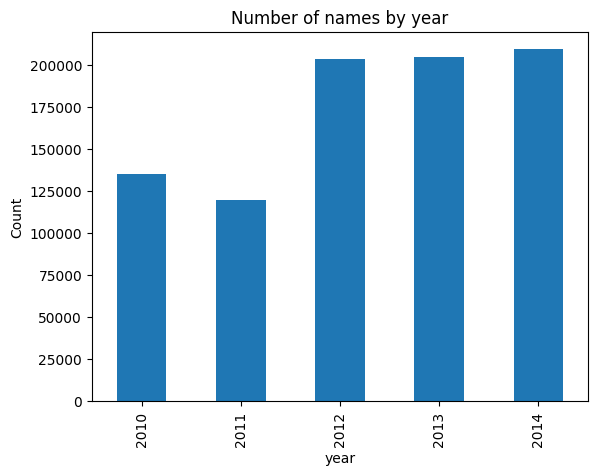

In [21]:
# Complete this cell with your code
# Group by 'year', count the number of 'name' entries, and plot as a vertical bar chart
df_names.groupby('year')['name'].count().plot(kind='bar', title='Number of names by year', ylabel='Count')